In [11]:
# ── Hardcoded reference energies (from previous run — kernel died) ─────────────
E_mof_T = {
    300:  -1170.927377,
    350:  -1169.929831,
    400:  -1168.871917,
    450:  -1167.828917,
    500:  -1167.054063,
    550:  -1166.128098,
    600:  -1165.371719,
    650:  -1164.211804,
    700:  -1163.518253,
    750:  -1162.268107,
    800:  -1161.478469,
    850:  -1160.795954,
    900:  -1160.017901,
    950:  -1158.307032,
    1000: -1157.488400,
}

E_co2_T = {
    300:  -22.522742,
    350:  -22.562976,
    400:  -22.524729,
    450:  -22.505545,
    500:  -22.508393,
    550:  -22.529646,
    600:  -22.446196,
    650:  -22.517010,
    700:  -22.488526,
    750:  -22.476538,
    800:  -22.561484,
    850:  -22.502157,
    900:  -22.446900,
    950:  -22.381456,
    1000: -22.426128,
}

E_mof  = E_mof_T[300]
E_co2  = E_co2_T[300]

print("Reference energies loaded from hardcoded values.")

Reference energies loaded from hardcoded values.


Found 15 trajectory files:
  300 K → /Users/christopherli/Documents/2026_Spring/cbe423/final-project/trajectories_gui_corrected/md_sitegui_300K_20260420_024224.traj
  350 K → /Users/christopherli/Documents/2026_Spring/cbe423/final-project/trajectories_gui_corrected/md_sitegui_350K_20260420_032042.traj
  400 K → /Users/christopherli/Documents/2026_Spring/cbe423/final-project/trajectories_gui_corrected/md_sitegui_400K_20260420_035825.traj
  450 K → /Users/christopherli/Documents/2026_Spring/cbe423/final-project/trajectories_gui_corrected/md_sitegui_450K_20260420_043613.traj
  500 K → /Users/christopherli/Documents/2026_Spring/cbe423/final-project/trajectories_gui_corrected/md_sitegui_500K_20260420_051401.traj
  550 K → /Users/christopherli/Documents/2026_Spring/cbe423/final-project/trajectories_gui_corrected/md_sitegui_550K_20260420_055138.traj
  600 K → /Users/christopherli/Documents/2026_Spring/cbe423/final-project/trajectories_gui_corrected/md_sitegui_600K_20260420_062923.traj
  650 K

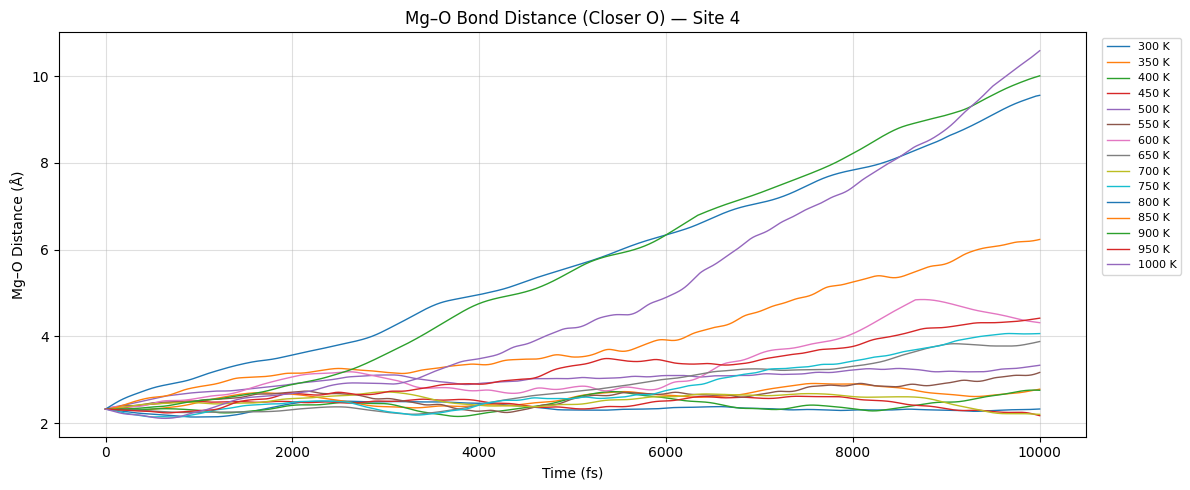

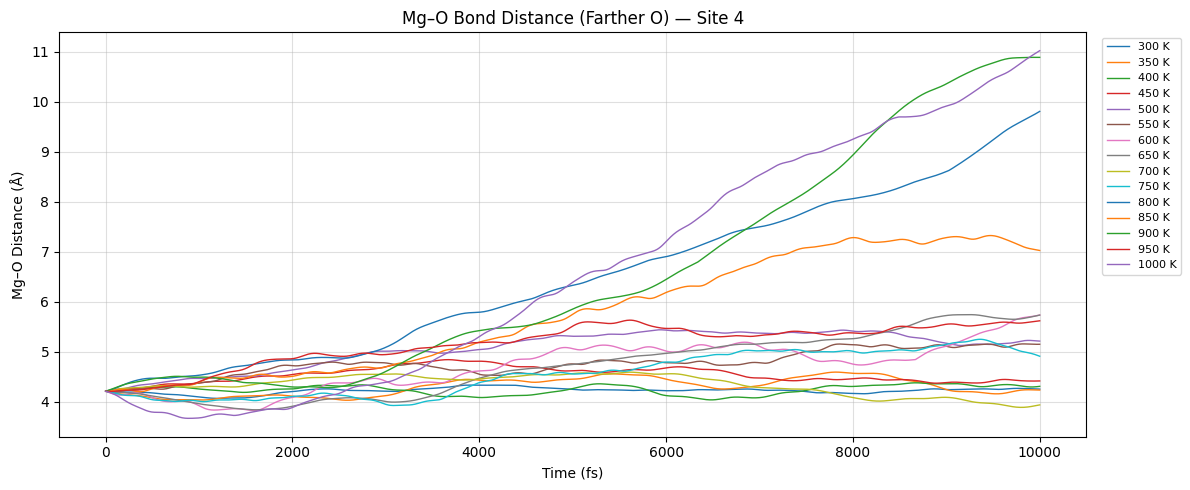

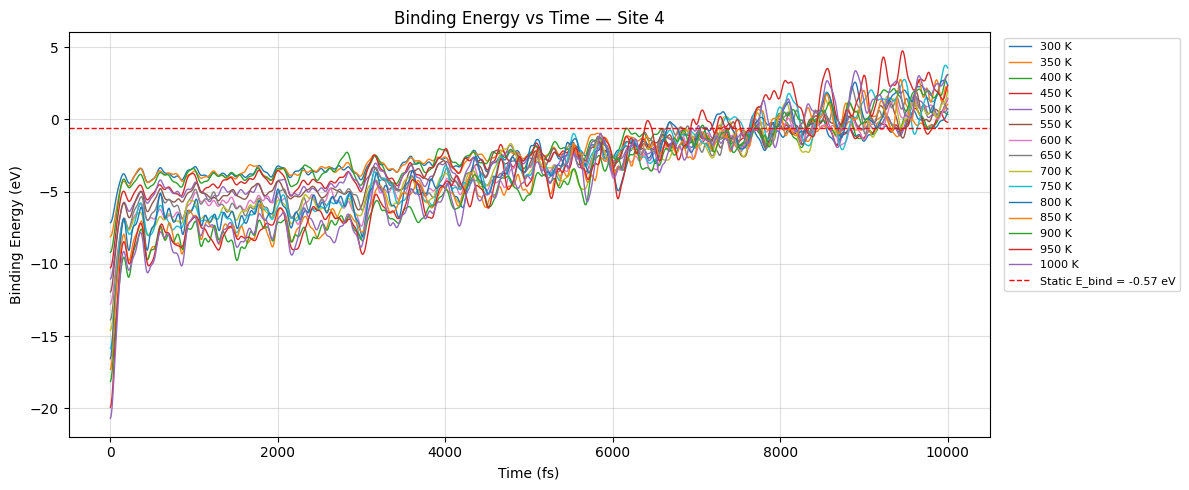

/var/folders/_z/4q19dfw93z98h599v771k7wr0000gn/T/ipykernel_1650/2153329301.py:140: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=8)


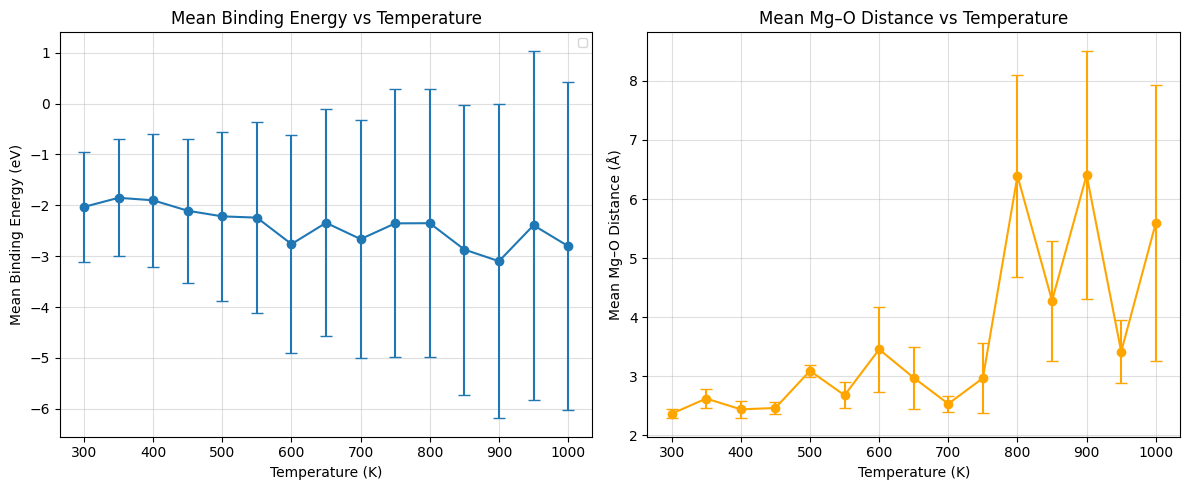


T (K)    <E_bind> (eV)      std        <Mg-O> (Å)      std       
------------------------------------------------------------
300      -2.0304            1.0803     2.366           0.078     
350      -1.8518            1.1515     2.623           0.164     
400      -1.9007            1.3028     2.440           0.149     
450      -2.1062            1.4191     2.464           0.110     
500      -2.2166            1.6622     3.093           0.104     
550      -2.2415            1.8807     2.678           0.219     
600      -2.7616            2.1453     3.456           0.720     
650      -2.3434            2.2297     2.975           0.529     
700      -2.6636            2.3340     2.534           0.136     
750      -2.3540            2.6362     2.968           0.587     
800      -2.3509            2.6338     6.393           1.709     
850      -2.8692            2.8511     4.279           1.014     
900      -3.0979            3.0887     6.405           2.105     
950      -2.39

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io.trajectory import Trajectory
import glob
import re
from datetime import datetime

# -------------------------------------------------------
# CONFIG — edit these
# -------------------------------------------------------
TRAJ_FOLDER  = "/Users/christopherli/Documents/2026_Spring/cbe423/final-project/trajectories_gui_corrected"   # folder containing your .traj files
MG_IDX       = 4                     # Mg site atom index
TIMESTEP_FS  = 1.0                   # MD timestep in fs
TRAJ_EVERY   = 10                    # interval used when writing frames
E_MOF        = -1177.415309              # replace with your E_mof value (eV)
E_CO2        = -22.596883              # replace with your E_co2 value (eV)
# -------------------------------------------------------

# Find and sort all trajectory files by temperature
traj_files = glob.glob(f"{TRAJ_FOLDER}/md_sitegui_*K_*.traj")

def extract_temp(fname):
    match = re.search(r'_(\d+)K_', fname)
    return int(match.group(1)) if match else 0

traj_files = sorted(traj_files, key=extract_temp)
temperatures = [extract_temp(f) for f in traj_files]

print(f"Found {len(traj_files)} trajectory files:")
for T, f in zip(temperatures, traj_files):
    print(f"  {T} K → {f}")

# -------------------------------------------------------
# Extract data from each trajectory
# -------------------------------------------------------
data = {}

for T, fpath in zip(temperatures, traj_files):
    traj = Trajectory(fpath, "r")

    times   = []
    mg_o_d1 = []
    mg_o_d2 = []
    e_bind  = []

    for i, atoms in enumerate(traj):
        time_fs = i * TIMESTEP_FS * TRAJ_EVERY

        # Mg-O distances (CO2 is last 3 atoms)
        co2_start = len(atoms) - 3
        o_indices = [j for j in range(co2_start, len(atoms)) if atoms[j].symbol == "O"]
        dists = sorted([atoms.get_distance(MG_IDX, o_idx, mic=True) for o_idx in o_indices])

        times.append(time_fs)
        mg_o_d1.append(dists[0])
        mg_o_d2.append(dists[1])
        e_bind.append(atoms.get_potential_energy() - E_mof_T[T] - E_co2_T[T])

    data[T] = {
        "times":   np.array(times),
        "mg_o_d1": np.array(mg_o_d1),
        "mg_o_d2": np.array(mg_o_d2),
        "e_bind":  np.array(e_bind),
    }
    print(f"  {T} K: {len(times)} frames loaded")

# -------------------------------------------------------
# Plot 1 — Mg-O bond distance (closer O) vs time
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
for T, d in data.items():
    ax.plot(d["times"], d["mg_o_d1"], lw=1.0, label=f"{T} K")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Mg–O Distance (Å)")
ax.set_title(f"Mg–O Bond Distance (Closer O) — Site {MG_IDX}")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"comparison_mg_o_closer_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# Plot 2 — Mg-O bond distance (farther O) vs time
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
for T, d in data.items():
    ax.plot(d["times"], d["mg_o_d2"], lw=1.0, label=f"{T} K")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Mg–O Distance (Å)")
ax.set_title(f"Mg–O Bond Distance (Farther O) — Site {MG_IDX}")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"comparison_mg_o_farther_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# Plot 3 — Binding energy vs time
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
for T, d in data.items():
    ax.plot(d["times"], d["e_bind"], lw=1.0, label=f"{T} K")
ax.axhline(-0.57, color="red", ls="--", lw=1, label="Static E_bind = -0.57 eV")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Binding Energy (eV)")
ax.set_title(f"Binding Energy vs Time — Site {MG_IDX}")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"comparison_binding_energy_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# Plot 4 — Mean binding energy vs temperature (summary)
# -------------------------------------------------------
eq_cut_frac = 0.2  # discard first 20% as equilibration

mean_e_bind = []
std_e_bind  = []
mean_mg_o   = []
std_mg_o    = []

for T in sorted(data.keys()):
    d      = data[T]
    eq_cut = int(len(d["times"]) * eq_cut_frac)
    mean_e_bind.append(d["e_bind"][eq_cut:].mean())
    std_e_bind.append(d["e_bind"][eq_cut:].std())
    mean_mg_o.append(d["mg_o_d1"][eq_cut:].mean())
    std_mg_o.append(d["mg_o_d1"][eq_cut:].std())

sorted_temps = sorted(data.keys())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.errorbar(sorted_temps, mean_e_bind, yerr=std_e_bind, fmt="o-", capsize=4)
#ax1.axhline(-0.57, color="red", ls="--", lw=1, label="Static E_bind = -0.57 eV")
ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel("Mean Binding Energy (eV)")
ax1.set_title("Mean Binding Energy vs Temperature")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.4)

ax2.errorbar(sorted_temps, mean_mg_o, yerr=std_mg_o, fmt="o-", capsize=4, color="orange")
ax2.set_xlabel("Temperature (K)")
ax2.set_ylabel("Mean Mg–O Distance (Å)")
ax2.set_title("Mean Mg–O Distance vs Temperature")
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(f"comparison_summary_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# Print summary table
# -------------------------------------------------------
print(f"\n{'T (K)':<8} {'<E_bind> (eV)':<18} {'std':<10} {'<Mg-O> (Å)':<15} {'std':<10}")
print("-" * 60)
for T, me, se, md, sd in zip(sorted_temps, mean_e_bind, std_e_bind, mean_mg_o, std_mg_o):
    print(f"{T:<8} {me:<18.4f} {se:<10.4f} {md:<15.3f} {sd:<10.3f}")

  300 K: 1001 frames loaded & MSD calculated
  350 K: 1001 frames loaded & MSD calculated
  400 K: 1001 frames loaded & MSD calculated
  450 K: 1001 frames loaded & MSD calculated
  500 K: 1001 frames loaded & MSD calculated
  550 K: 1001 frames loaded & MSD calculated
  600 K: 1001 frames loaded & MSD calculated
  650 K: 1001 frames loaded & MSD calculated
  700 K: 1001 frames loaded & MSD calculated
  750 K: 1001 frames loaded & MSD calculated
  800 K: 1001 frames loaded & MSD calculated
  850 K: 1001 frames loaded & MSD calculated
  900 K: 1001 frames loaded & MSD calculated
  950 K: 1001 frames loaded & MSD calculated
  1000 K: 1001 frames loaded & MSD calculated


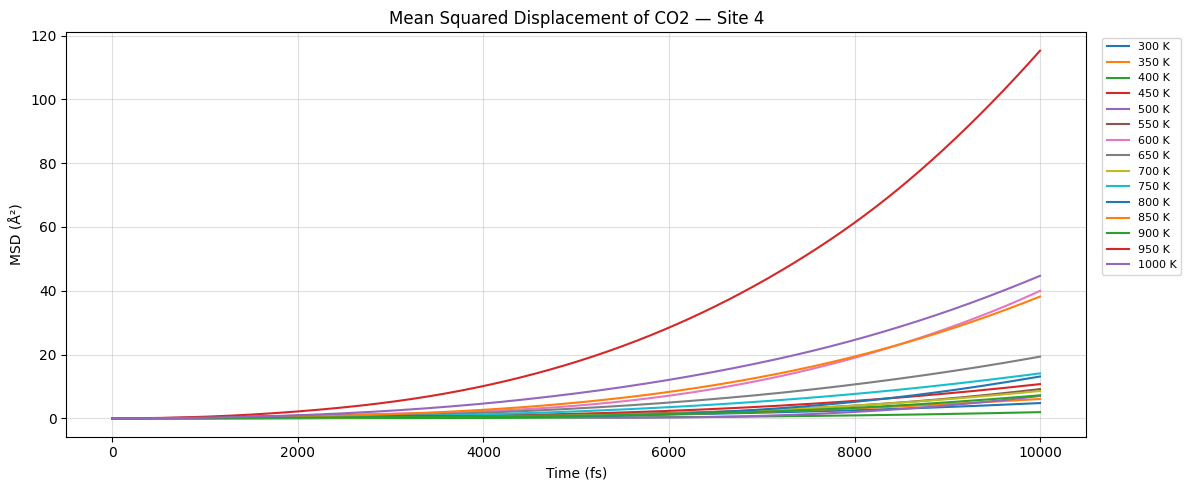

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io.trajectory import Trajectory
import glob
import re
from datetime import datetime

# -------------------------------------------------------
# CONFIG — edit these
# -------------------------------------------------------
TRAJ_FOLDER  = "/Users/christopherli/Documents/2026_Spring/cbe423/final-project/trajectories_2"
MG_IDX       = 4
TIMESTEP_FS  = 1.0
TRAJ_EVERY   = 10
E_MOF        = -1177.415309
E_CO2        = -22.596883

# Note: In your original snippet, E_mof_T and E_co2_T were used. 
# If they are constants, I'll use E_MOF and E_CO2.
# -------------------------------------------------------

traj_files = glob.glob(f"{TRAJ_FOLDER}/md_site4_*K_*.traj")

def extract_temp(fname):
    match = re.search(r'_(\d+)K_', fname)
    return int(match.group(1)) if match else 0

traj_files = sorted(traj_files, key=extract_temp)
temperatures = [extract_temp(f) for f in traj_files]

data = {}

for T, fpath in zip(temperatures, traj_files):
    traj = Trajectory(fpath, "r")

    times   = []
    mg_o_d1 = []
    mg_o_d2 = []
    e_bind  = []
    com_positions = [] # To store Center of Mass

    for i, atoms in enumerate(traj):
        time_fs = i * TIMESTEP_FS * TRAJ_EVERY
        
        # 1. Identify CO2 atoms
        co2_indices = list(range(len(atoms) - 3, len(atoms)))
        
        # 2. Get Center of Mass (Important: use get_positions with wrap=False for diffusion)
        # Note: This assumes your trajectory has unwrapped coordinates. 
        # If not, use atoms.get_center_of_mass(indices=co2_indices)
        com = atoms[co2_indices].get_center_of_mass()
        com_positions.append(com)

        # Mg-O distances
        o_indices = [j for j in co2_indices if atoms[j].symbol == "O"]
        dists = sorted([atoms.get_distance(MG_IDX, o_idx, mic=True) for o_idx in o_indices])

        times.append(time_fs)
        mg_o_d1.append(dists[0])
        mg_o_d2.append(dists[1])
        # Using the constant energy values defined in config
        e_bind.append(atoms.get_potential_energy() - E_MOF - E_CO2)

    # Calculate MSD: |r(t) - r(0)|^2
    com_positions = np.array(com_positions)
    displacements = com_positions - com_positions[0]
    sq_displacements = np.sum(displacements**2, axis=1)

    data[T] = {
        "times":   np.array(times),
        "mg_o_d1": np.array(mg_o_d1),
        "mg_o_d2": np.array(mg_o_d2),
        "e_bind":  np.array(e_bind),
        "msd":     sq_displacements,
    }
    print(f"  {T} K: {len(times)} frames loaded & MSD calculated")

# -------------------------------------------------------
# NEW Plot — Mean Squared Displacement (MSD) vs Time
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))
for T, d in data.items():
    ax.plot(d["times"], d["msd"], lw=1.5, label=f"{T} K")

ax.set_xlabel("Time (fs)")
ax.set_ylabel("MSD (Å²)")
ax.set_title(f"Mean Squared Displacement of CO2 — Site {MG_IDX}")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"msd_comparison_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png", dpi=150)
plt.show()

# -------------------------------------------------------
# (Your original Plot 1, 2, 3, and Summary Plot 4 follow here)
# -------------------------------------------------------

In [21]:
from ase.io import read
from ase.visualize import view

trajectory = read("/Users/christopherli/Documents/2026_Spring/cbe423/final-project/trajectories_gui_corrected/md_sitegui_300K_20260420_024224.traj", index=":")

view(trajectory)

<Popen: returncode: None args: ['/Users/christopherli/miniconda3/envs/cms/bi...>

In [20]:
atoms = read("mof_co2_initial.cif")
view(atoms)

<Popen: returncode: None args: ['/Users/christopherli/miniconda3/envs/cms/bi...>